In [2]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import Dense

In [3]:
df = pd.read_csv('/content/loan_data.csv')

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3600/3600 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8219 - loss: 0.4112
Epoch 2/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8288 - loss: 0.3886
Epoch 3/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8327 - loss: 0.3821
Epoch 4/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8359 - loss: 0.3798
Epoch 5/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8380 - loss: 0.3782
Epoch 6/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8381 - loss: 0.3776
Epoch 7/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8387 - loss: 0.3773
Epoch 8/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8397 - loss: 0.3768
Epoch 9/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8393 - loss: 0.3761
Epoch 10/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8391 - loss: 0.3767
Epoch 11/100
3600/3600 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8398 - loss: 0.3763
Epoch 12/100
3600/3600 ━━━━━━━━

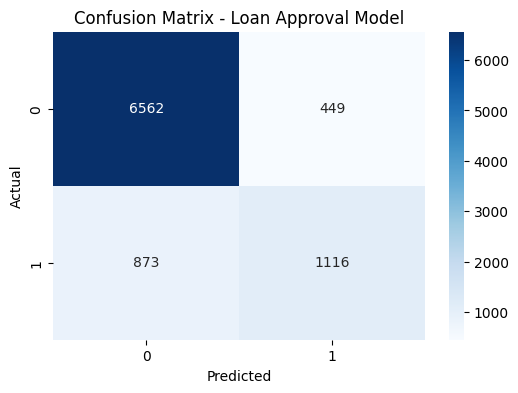

In [5]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

X = df.iloc[:, [3, 8, 9, 11]].values
y = df.iloc[:, 13].values

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0
)

# Feature Scaling
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Initialising the ANN
classifier = Sequential()

# adding input layer and the first hidden layer
classifier.add(Dense(
    units=7,
    kernel_initializer='uniform',
    activation='relu',
    input_dim=4
))

# adding 2nd hidden layer
classifier.add(Dense(
    units=7,
    kernel_initializer='uniform',
    activation='relu'
))

# adding output layer
classifier.add(Dense(
    units=1,
    kernel_initializer='uniform',
    activation='sigmoid'
))

# compiling the ANN
classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Fit ANN to the train set
classifier.fit(
    X_train,
    y_train,
    batch_size=10,
    epochs=100
)

# Predict test data
y_pred = classifier.predict(X_test)

# Convert probabilities into 0 and 1
y_pred = (y_pred > 0.5)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Final Accuracy:", accuracy * 100, "%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Loan Approval Model')
plt.show()